In [ ]:
!wget --no-check-certificate \
https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip

--2024-08-21 04:09:58--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.200.207, 74.125.130.207, 74.125.68.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.200.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘cats_and_dogs_filtered.zip’

cats_and_dogs_filte 100%[===================>]  65.43M  20.5MB/s    in 4.0s    

2024-08-21 04:10:02 (16.3 MB/s) - ‘cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [ ]:
import os
import zipfile

local_zip = '/content/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')

In [ ]:
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
# 기본 경로
base_dir = '/content/cats_and_dogs_filtered'

# 훈련용 디렉토리
train_dir = os.path.join(base_dir, 'train')

# 검증용 디렉토리
validation_dir = os.path.join(base_dir, 'validation')

print(train_dir)
print(validation_dir)

/content/cats_and_dogs_filtered/train
/content/cats_and_dogs_filtered/validation


In [ ]:
# 훈련에 사용되는 개, 고양이 디렉토리 경로
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
print(train_cats_dir)
print(train_dogs_dir)

/content/cats_and_dogs_filtered/train/cats
/content/cats_and_dogs_filtered/train/dogs


In [ ]:
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
print(validation_cats_dir)
print(validation_dogs_dir)

/content/cats_and_dogs_filtered/validation/cats
/content/cats_and_dogs_filtered/validation/dogs


In [ ]:
train_cats_fnames = os.listdir(train_cats_dir)
train_dogs_fnames = os.listdir(train_dogs_dir)
print(train_cats_fnames[:5])
print(train_dogs_fnames[:5])

['cat.664.jpg', 'cat.418.jpg', 'cat.580.jpg', 'cat.440.jpg', 'cat.302.jpg']
['dog.399.jpg', 'dog.950.jpg', 'dog.854.jpg', 'dog.278.jpg', 'dog.234.jpg']


In [ ]:
print('학습용 고양이 사진의 수 :', len(train_cats_fnames))
print('학습용 강아지 사진의 수 :', len(train_dogs_fnames))

학습용 고양이 사진의 수 : 1000
학습용 강아지 사진의 수 : 1000


In [ ]:
validation_cats_fnames = os.listdir(validation_cats_dir)
validation_dogs_fnames = os.listdir(validation_dogs_dir)
print(validation_cats_fnames[:5])
print(validation_dogs_fnames[:5])

['cat.2185.jpg', 'cat.2167.jpg', 'cat.2304.jpg', 'cat.2208.jpg', 'cat.2261.jpg']
['dog.2393.jpg', 'dog.2477.jpg', 'dog.2102.jpg', 'dog.2216.jpg', 'dog.2164.jpg']


In [ ]:
print('학습용 고양이 사진의 수 :', len(validation_cats_fnames))
print('학습용 강아지 사진의 수 :', len(validation_dogs_fnames))

학습용 고양이 사진의 수 : 500
학습용 강아지 사진의 수 : 500


In [ ]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

nrows, ncols = 4, 4
pic_index = 0
fig = plt.gcf()
fig.set_size_inches(ncols*3, nrows+3)
pic_index += 8

next_cat_pix = [os.path.join(train_cats_dir, fname) for fname in train_cats_fnames[pic_index-8:pic_index]]
next_dog_pix = [os.path.join(train_dogs_dir, fname) for fname in train_dogs_fnames[pic_index-8:pic_index]]

next_cat_pix

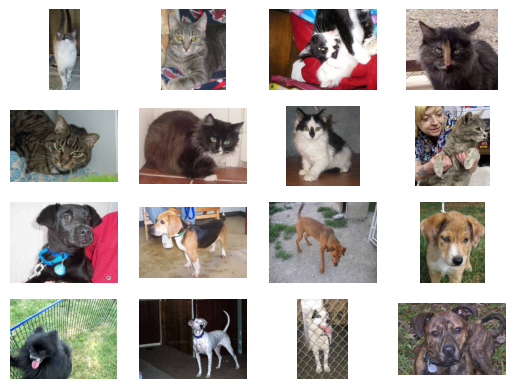

In [ ]:
for i, img_path in enumerate(next_cat_pix+next_dog_pix):
  sp = plt.subplot(nrows, ncols, i+1)
  sp.axis('Off')
  img = mpimg.imread(img_path)
  plt.imshow(img)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(train_dir,
                                                  batch_size = 32,
                                                  target_size = (150, 150),
                                                  class_mode = 'binary')

Found 2000 images belonging to 2 classes.


In [ ]:
validation_generator = validation_datagen.flow_from_directory(validation_dir,
                                                            batch_size = 32,
                                                            target_size = (150, 150),
                                                            class_mode = 'binary')

Found 1000 images belonging to 2 classes.


In [ ]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Input, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(150,150,3)))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = 2, padding = 'same'))
model.add(Dropout(0,2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer = Adam(1e-4),
              loss = 'binary_crossentropy',
              metrics = ['acc'])

In [ ]:
model.summary()

In [ ]:
history = model.fit(train_generator,
                    epochs = 20,
                    validation_data = validation_generator)

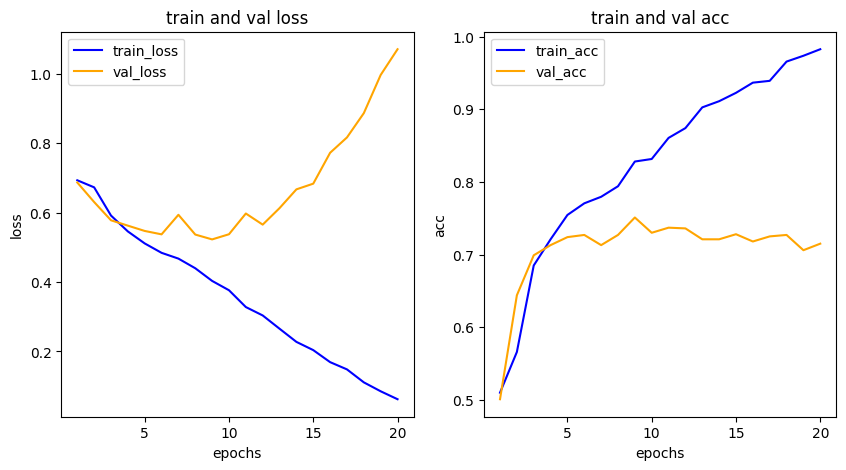

In [ ]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

예측

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def pred(fname):
  img = image.load_img(fname, target_size=(150,150))
  plt.imshow(img)
  x = image.img_to_array(img)/255
  images = np.expand_dims(x, axis=0)
  classes = model.predict(images, batch_size=1)
  print(classes[0])
  if classes[0] > 0.5:
    print(fname.split('/')[-1] + '사진은 강아지 입니다.')
  else:
    print(fname.split('/')[-1] + '사진은 고양이 입니다.')

In [ ]:
uploaded = files.upload()

Saving 강아지.jpg to 강아지.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
[8.611481e-05]
cat.10.jpg사진은 고양이 입니다.


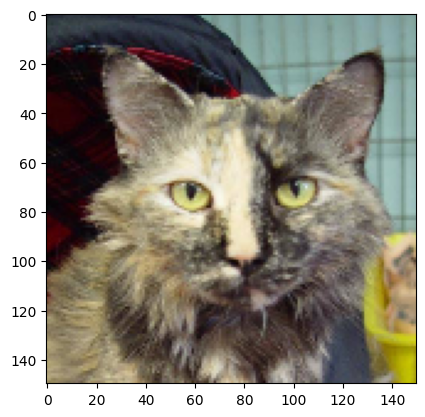

In [ ]:
pred('/content/cats_and_dogs_filtered/train/cats/cat.10.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[0.9967309]
dog.115.jpg사진은 강아지 입니다.


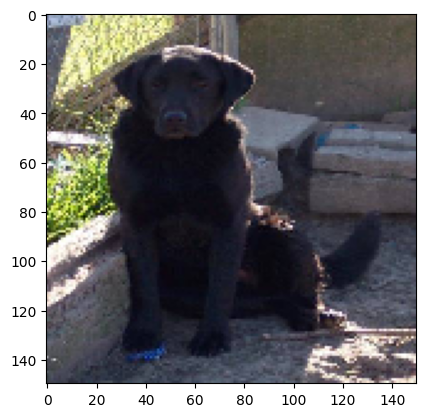

In [ ]:
pred('/content/cats_and_dogs_filtered/train/dogs/dog.115.jpg')